# 📉 Notebook 03: ML Fundamentals
## Bias-Variance Trade-off & Learning Curves

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from src.utils import load_numpy
from src.tree_models import train_decision_tree_classifier

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
y_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_binary.npy"))

indices = np.random.choice(len(X_train), 20000, replace=False)
X_sub = X_train[indices]
y_sub = y_train[indices]

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_binary.npy | Shape: (125973,)


📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_test.npy | Shape: (22544, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_binary.npy | Shape: (22544,)


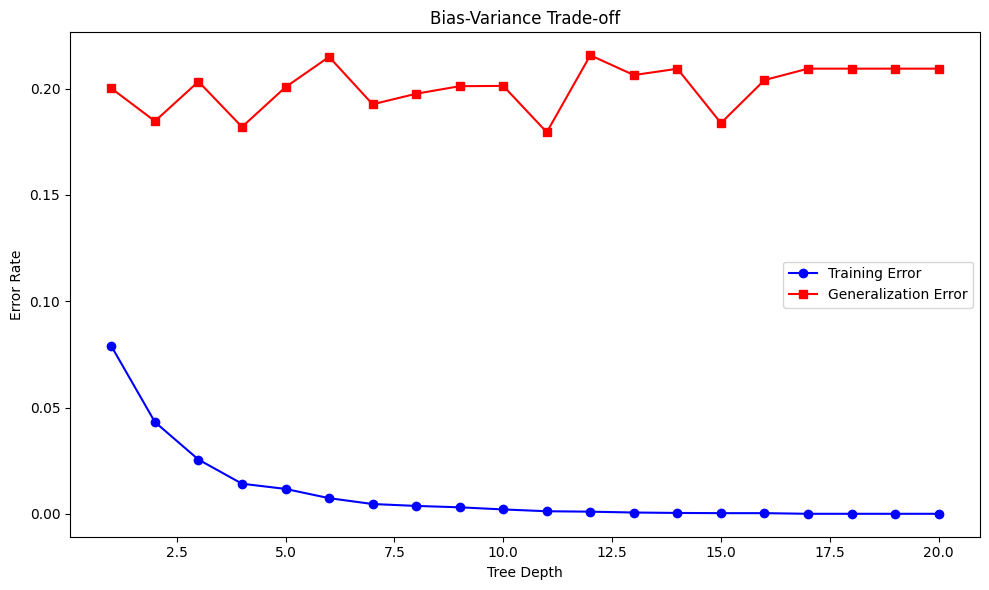

In [2]:
depths = list(range(1, 21))
train_errs = []
test_errs = []

X_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_test.npy"))
y_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_binary.npy"))

for d in depths:
    clf = train_decision_tree_classifier(X_sub, y_sub, max_depth=d)
    train_errs.append(1.0 - clf.score(X_sub, y_sub))
    test_errs.append(1.0 - clf.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_errs, label="Training Error", color="blue", marker="o")
ax.plot(depths, test_errs, label="Generalization Error", color="red", marker="s")
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Error Rate")
ax.set_title("Bias-Variance Trade-off")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module1", "bias_variance_tradeoff.png"), dpi=150)
plt.show()

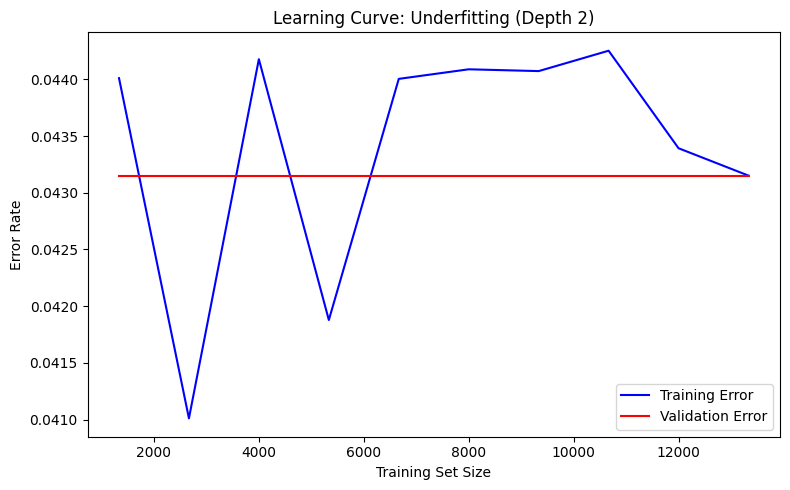

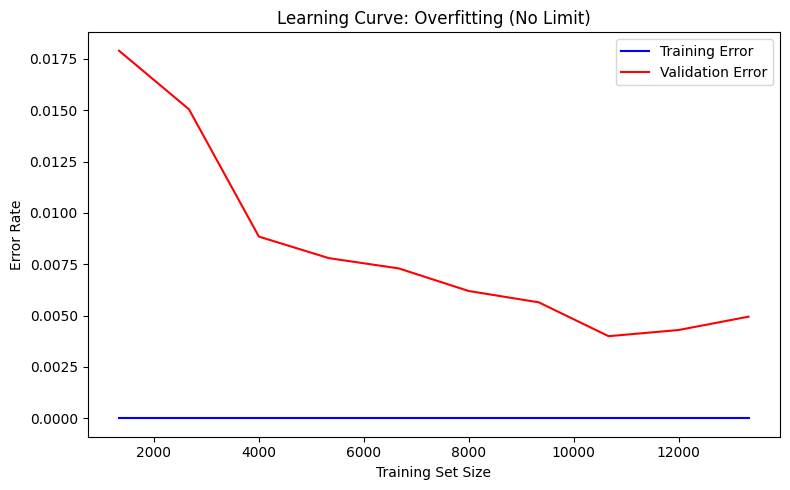

In [3]:
models_to_curve = {
    "Underfitting (Depth 2)": train_decision_tree_classifier(X_sub, y_sub, max_depth=2),
    "Overfitting (No Limit)": train_decision_tree_classifier(X_sub, y_sub, max_depth=None)
}

for name, model in models_to_curve.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_sub, y_sub, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
    )
    
    train_mean = 1.0 - np.mean(train_scores, axis=1)
    test_mean = 1.0 - np.mean(test_scores, axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_mean, label="Training Error", color="blue")
    ax.plot(train_sizes, test_mean, label="Validation Error", color="red")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Error Rate")
    ax.set_title(f"Learning Curve: {name}")
    ax.legend()
    plt.tight_layout()
    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module1", f"learning_curve_{fname}.png"), dpi=150)
    plt.show()